# Deconvolution of Spatial Wavelet Coefficient Representation of Chromatin Images
February 15, 2024

A notebook to test the idea of whether we can deconvolve wavelet coefficients of the chromatin image data.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [204]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [364]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [365]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)

In [366]:
chrom_wavelets.create_coefficients()

Created coefficients matrix of shape: (16, 4, 12, 29)
Created coefficients vectorized matrix of shape: (16, 1392)


In [367]:
recon_coefficients_mat = chrom_wavelets.convert_vectorized_coeffs_to_mat(chrom_wavelets.coeffs_vec)


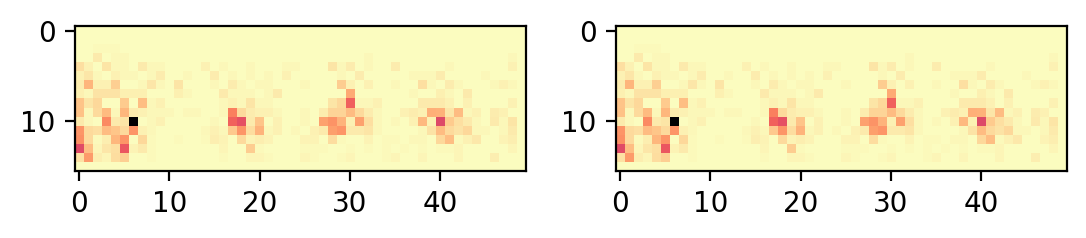

In [368]:
imgs = chrom_wavelets.reconstruct_images(recon_coefficients_mat)
imgs[imgs < 0] = 0

plt.subplot(1, 2, 1)
plt.imshow(chromatin_model.deconv_hist_unflattened[0], cmap='magma_r')

plt.subplot(1, 2, 2)
plt.imshow(imgs[0], cmap='magma_r')


In [294]:
# Now, can we deconvolve the coefficients vector?
chromatin_model.setup_deconv_model()
deconv_model = chromatin_model.deconv_model

In [369]:
G = chrom_wavelets.coeffs_vec

In [370]:

# Threshold G, such that there are non negative values
# This effectively compresses the coefficient matrix
# and removes negative values from G which would cause issues with the solver.
G = chrom_wavelets.coeffs_vec.copy()


0

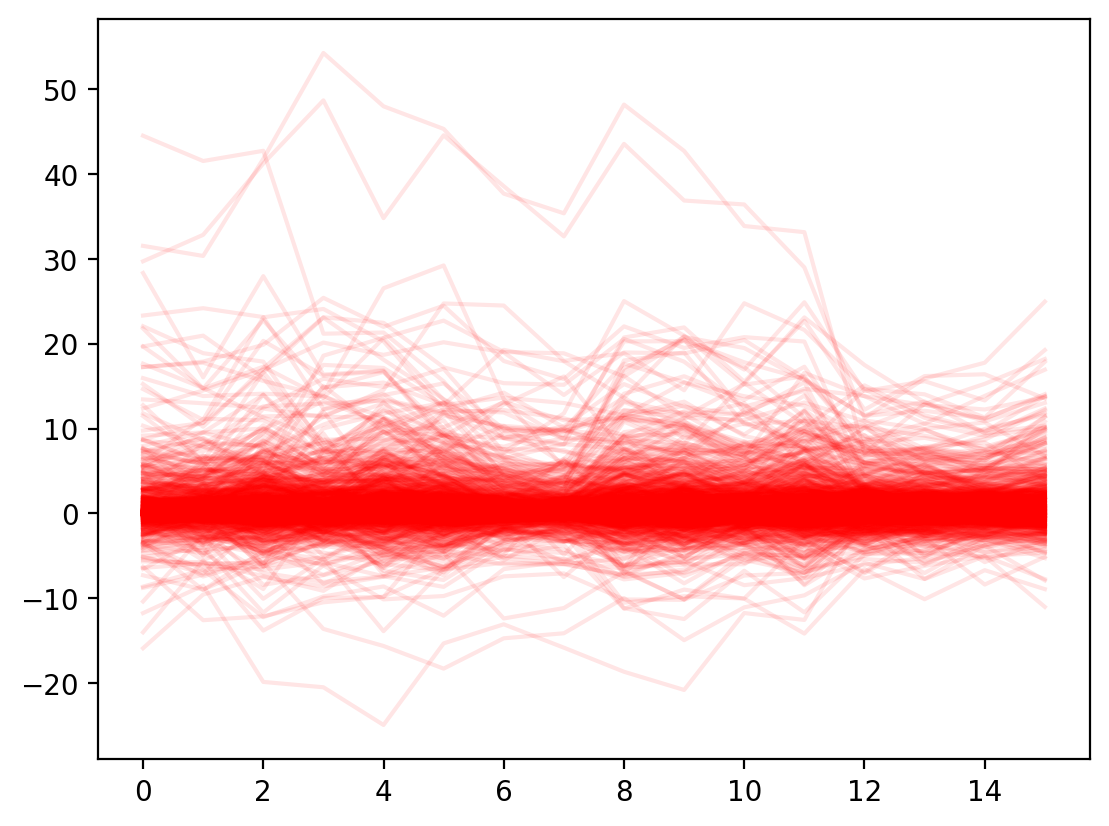

In [371]:
plt.plot(G[:, :], c='red', alpha=0.1)
0

0

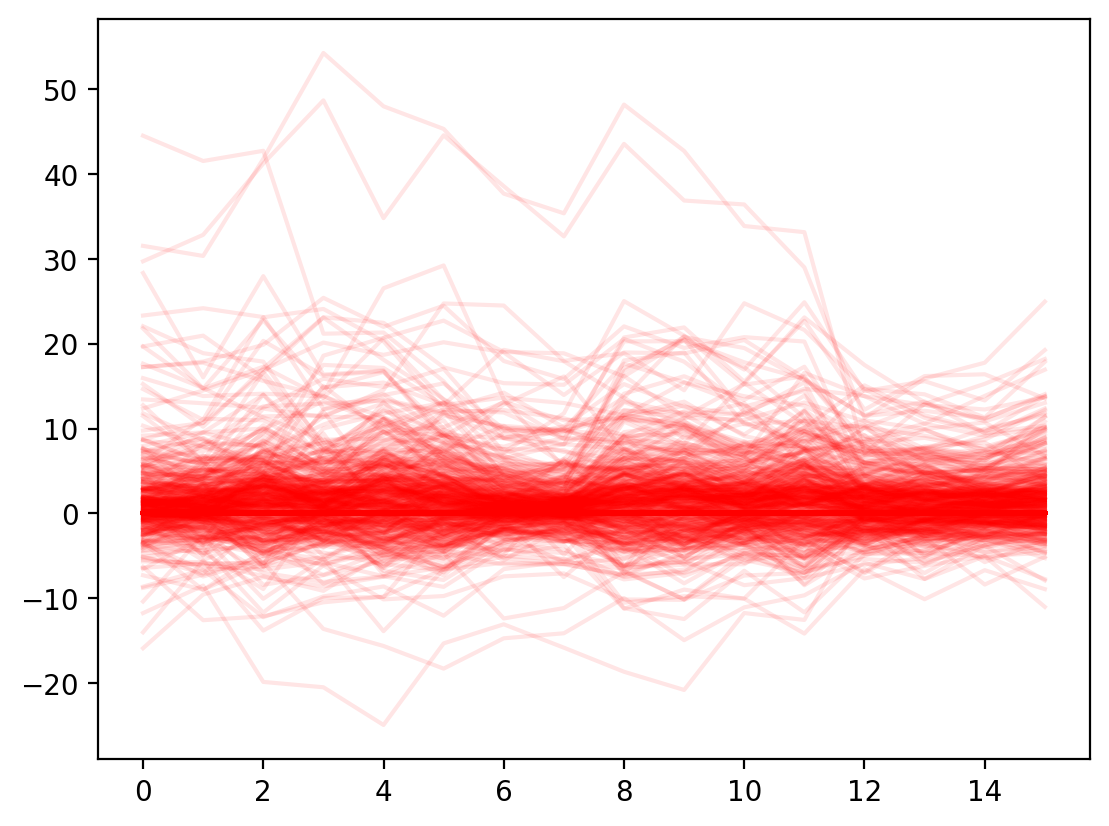

In [372]:
# Enforce that the coefficient must have some value at any timepoint above abs 3
G_thresholded = G.copy()
G_thresholded[:, np.abs(G_thresholded).max(axis=0) < 3] = 0
plt.plot(G_thresholded, c='red', alpha=0.1)
0

In [424]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

chromatin_model.gamma = 1e-3
deconv_model.gamma = 1e-3
f, rn, sn = deconvolve_chromatin_H(deconv_model, deconv_model.H, G_thresholded, verbose=True,
                                  allow_negative=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 15 02:51:00 PM: Your problem has 315984 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 15 02:51:00 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 15 02:51:00 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 15 02:51:00 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 15 02:51:00 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 15 02:51:00 PM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 15 02:53:41 PM: 26  7.8e-04  1.6e-03  7.7e-05  7.63e-01   2.757413177e+03   2.757413901e+03   7.8e-04  66.54 
(CVXPY) Feb 15 02:53:42 PM: 27  6.6e-04  1.3e-03  6.1e-05  7.66e-01   2.683964782e+03   2.683965342e+03   6.6e-04  67.11 
(CVXPY) Feb 15 02:53:43 PM: 28  5.7e-04  1.1e-03  5.1e-05  7.59e-01   2.630541012e+03   2.630541465e+03   5.7e-04  67.70 
(CVXPY) Feb 15 02:53:43 PM: 29  4.8e-04  9.7e-04  4.1e-05  7.56e-01   2.564577683e+03   2.564578019e+03   4.8e-04  68.34 
(CVXPY) Feb 15 02:53:44 PM: 30  4.2e-04  8.5e-04  3.5e-05  7.53e-01   2.516983925e+03   2.516984188e+03   4.2e-04  69.01 
(CVXPY) Feb 15 02:53:45 PM: 31  3.6e-04  7.2e-04  2.8e-05  7.44e-01   2.459419812e+03   2.459419993e+03   3.6e-04  69.69 
(CVXPY) Feb 15 02:53:45 PM: 32  3.1e-04  6.1e-04  2.3e-05  7.44e-01   2.407490795e+03   2.407490915e+03   3.1e-04  70.33 
(CVXPY) Feb 15 02:53:46 PM: 33  2.3e-04  4.6e-04  1.5e-05  7.49e-01   2.318608712e+03   2.318608744e+03   2.3e-04  71.17 
(CVXPY) Feb 15 02:53:47 

In [425]:
f_coeffs_mats = chrom_wavelets.convert_vectorized_coeffs_to_mat(f)
f_imgs = chrom_wavelets.reconstruct_images(f_coeffs_mats)
origin_coeffs_mat = chrom_wavelets.coefficients_matrix

In [426]:
imgs = chrom_wavelets.reconstruct_images(f_coeffs_mats)
imgs.shape

(227, 16, 50)

In [427]:
pred_G_vec = np.matmul(deconv_model.H, f)
pred_G_coeffs_mats = chrom_wavelets.convert_vectorized_coeffs_to_mat(pred_G_vec)
pred_G_imgs = chrom_wavelets.reconstruct_images(pred_G_coeffs_mats)

test_coeffs = chrom_wavelets.coefficients_matrix
G_imgs = chrom_wavelets.reconstruct_images(test_coeffs)

plt_imgs = pred_G_imgs.copy()
plt_imgs[plt_imgs < 0] = 0

G_imgs[G_imgs < 0] = 0

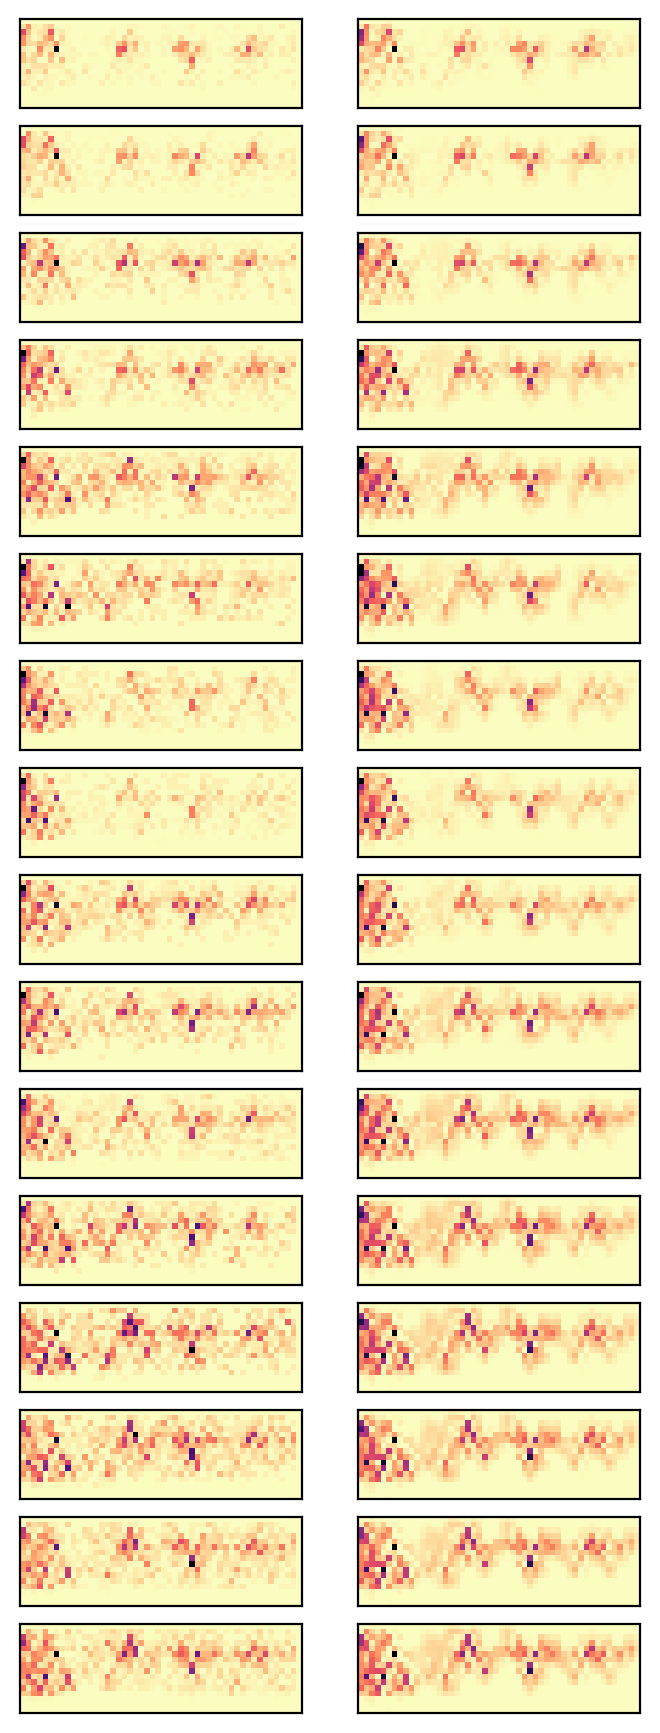

In [428]:
n = G_imgs.shape[0]

plt.figure(figsize=(4, 11))
for i in range(n):

    plt.subplot(n, 2, 2*i+1)
    plt.imshow(G_imgs[i], cmap='magma_r', origin='lower', aspect='auto')
    plt.xticks([])
    plt.yticks([])
    plt.subplot(n, 2, 2*i+2)
    plt.imshow(plt_imgs[i], cmap='magma_r', origin='lower', aspect='auto')
    plt.xticks([])
    plt.yticks([])


0

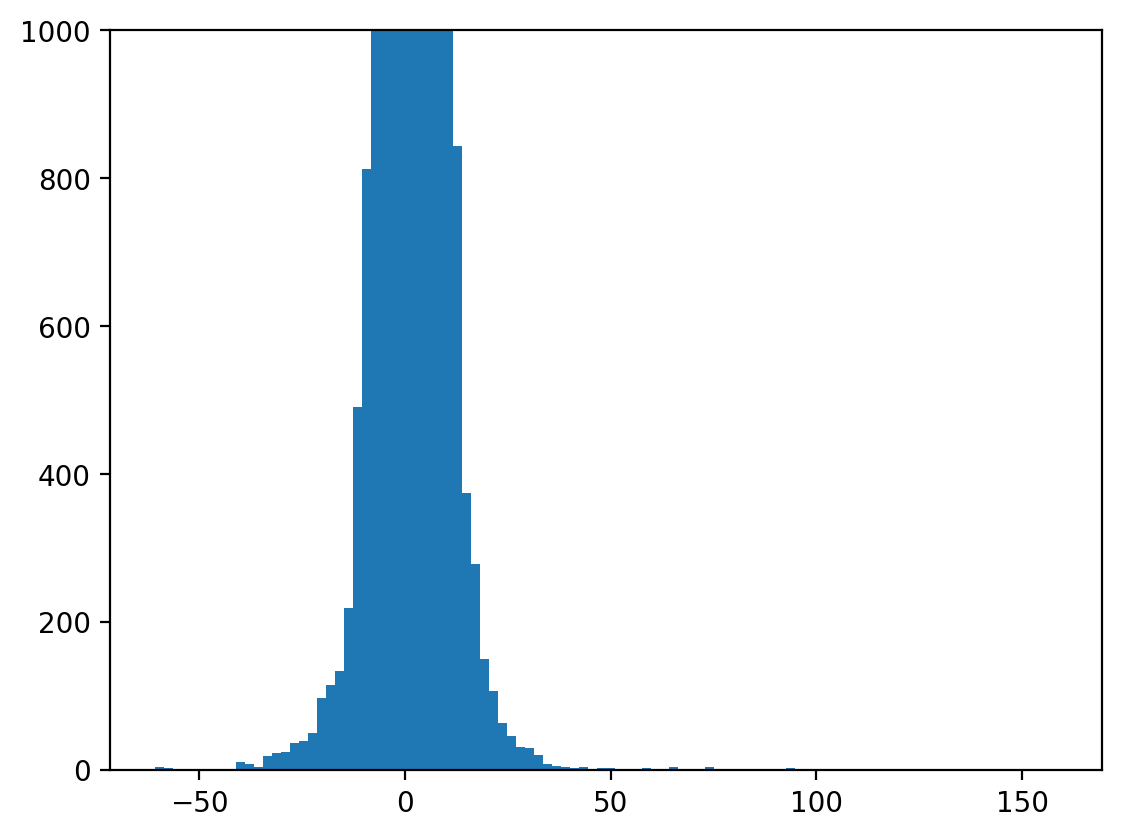

In [429]:
plt.hist(f_imgs.flatten(), bins=100)
plt.ylim(0, 1000)
0

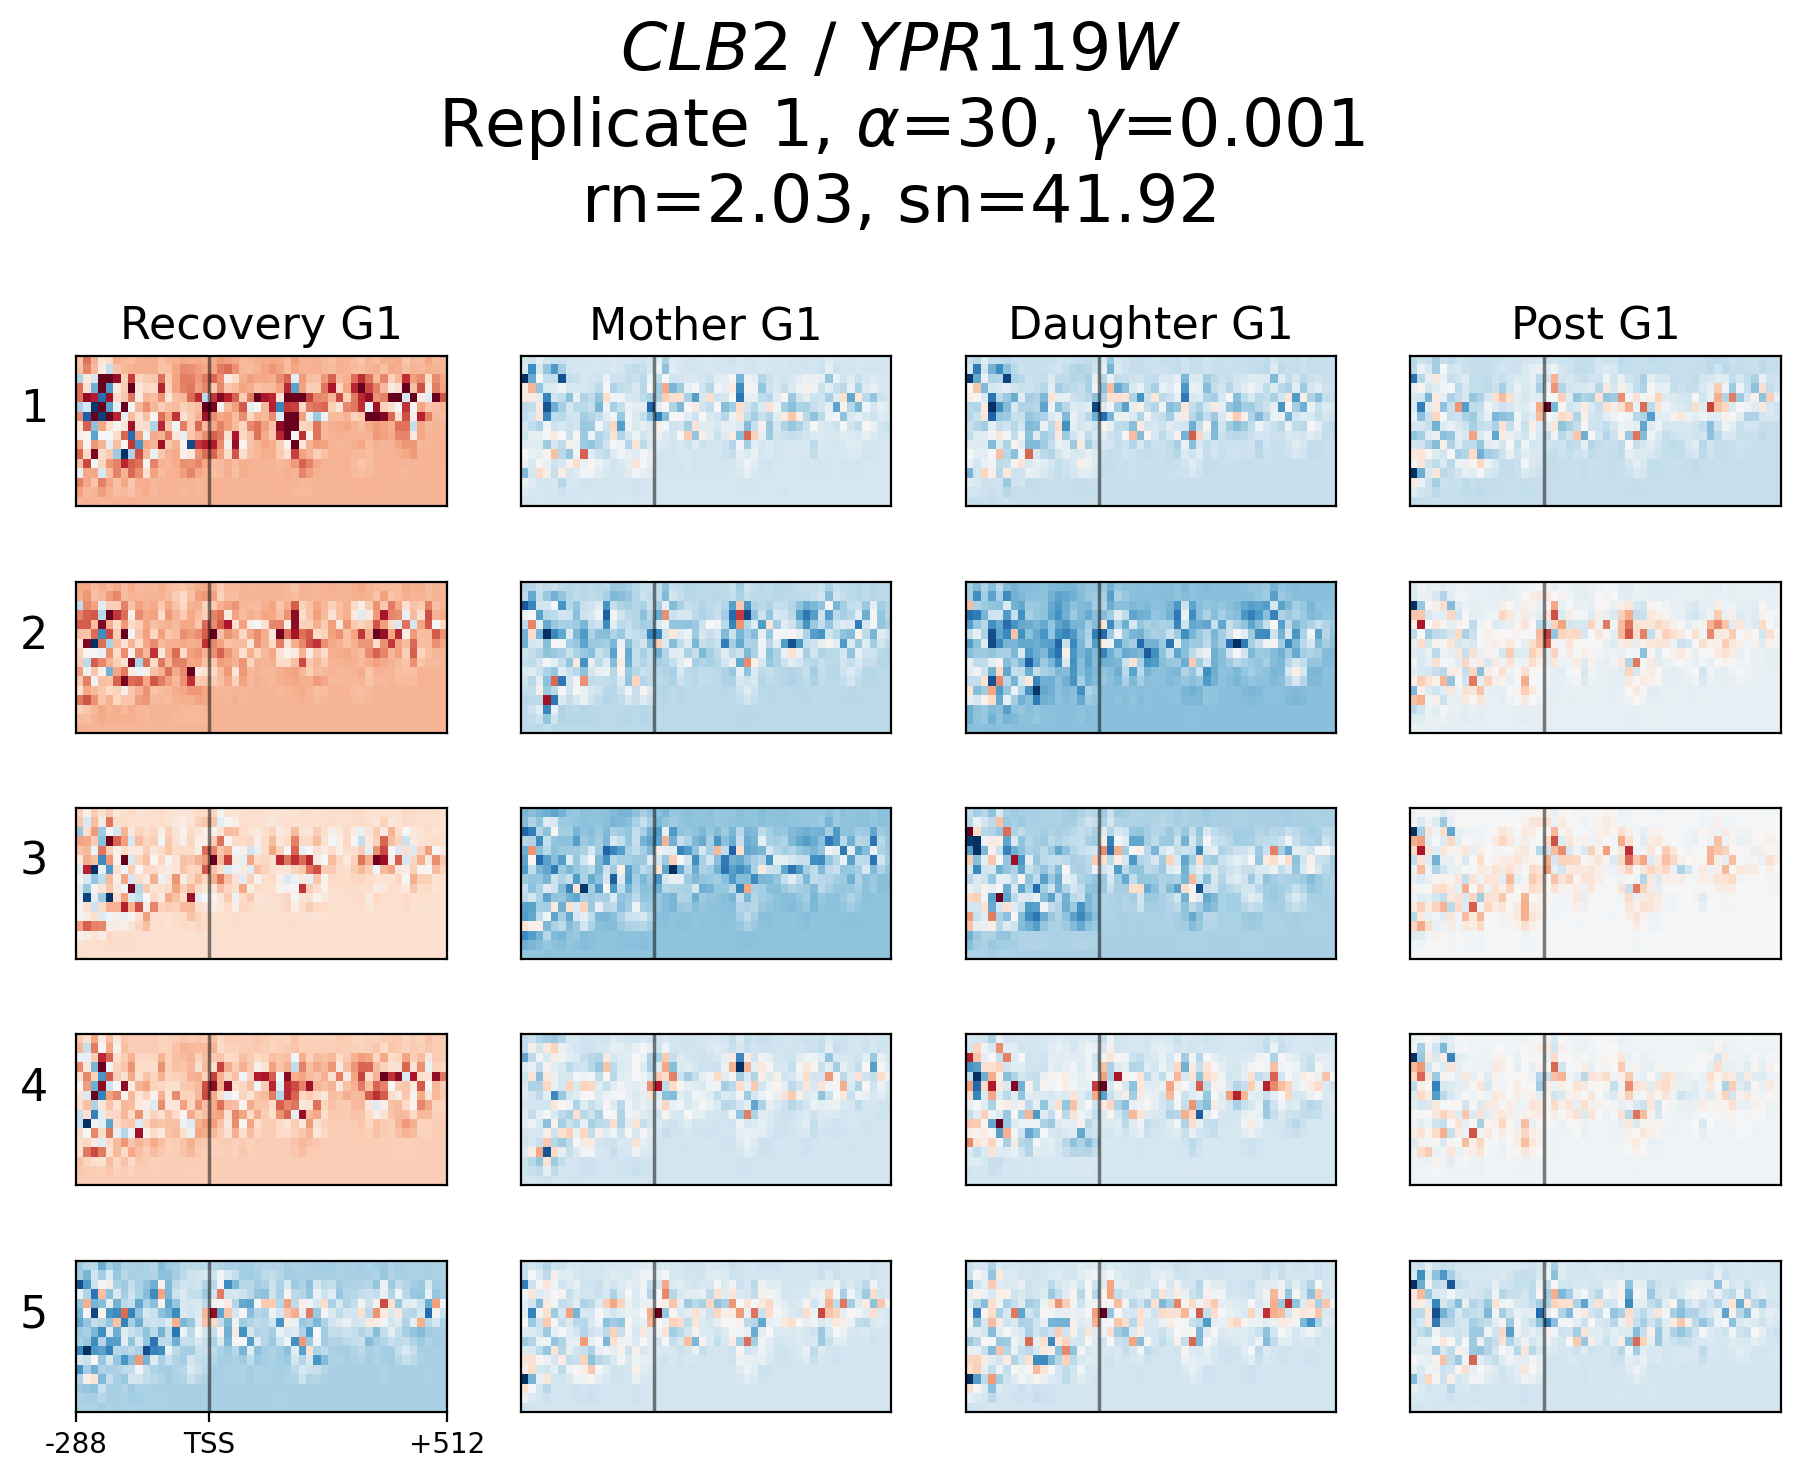

In [433]:
f_imgs_plt = f_imgs.copy()
#f_imgs_plt[f_imgs_plt < 0] = 0
chromatin_model.f = f_imgs_plt

fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmin=-20, vmax=20)